# DATA 266 Lab 1 — Task 1: GPT-style character LM from scratch
**Member:** Rajesh Paruchuri · **Dataset:** TinyStories (`roneneldan/TinyStories`, train shard 0)

All Transformer parts are hand-written in `char_gpt.py`: LayerNorm, causal multi-head self-attention,
the feed-forward block, residual wiring, learnable token and positional embeddings, and a weight-tied LM head.
No `nn.Transformer*`, `nn.MultiheadAttention` or `F.scaled_dot_product_attention` is used.

Run everything (repo root): `jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=-1 task1_llm/rajesh_paruchuri/src/part1_llm.ipynb`
· smoke test: prefix with `LAB_SMOKE=1`.

In [1]:
import json, math, sys, time
from pathlib import Path
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()) if (Path.cwd() / "char_gpt.py").exists() else str(Path.cwd() / "task1_llm/rajesh_paruchuri/src"))
import char_gpt as cg

P = cg.find_paths()
R = lambda p: cg.rel(p, P["repo"])
CFG = cg.load_config(P)
SMOKE = bool(CFG["smoke"])
TAG = "smoke" if SMOKE else "full"
cg.set_seed(CFG["seed"])
device = cg.pick_device()
print("smoke:", SMOKE, "| seed:", CFG["seed"], "| device:", device, "|", cg.hardware_string(device))
print("torch", torch.__version__, "| numpy", np.__version__, "| python", sys.version.split()[0])

smoke: False | seed: 266 | device: mps | MPS (Apple GPU) on Apple M4
torch 2.11.0 | numpy 2.3.3 | python 3.13.7


## 1.1 Data preprocessing
1. Load TinyStories and clean it: fold curly quotes/dashes to ASCII, and drop empty or very short (<50 chars) entries.
2. **My own split, story-disjoint.** Stories are shuffled with seed 266. The first stories fill the validation stream
   and the remaining ones fill the training stream, so no story is split across train and val. Every story ends with an
   end-of-story character (`<|eos|>`), which the model learns to emit and generation uses as a stop signal.
3. Character tokenisation with my own `char_to_idx` / `idx_to_char`, built **from the train stream only**.
   Characters seen fewer than 25 times map to `<unk>`.
4. Each stream is cut into non-overlapping windows of `block_size + 1 = 193` characters: `x = w[:-1]`, `y = w[1:]`.
   That gives exactly 100,000 train and 10,000 validation sequences.

In [2]:
raw_path = cg.download_if_missing(CFG, P)
stories, clean_info = cg.load_stories(raw_path, CFG["min_story_chars"])
lens = np.array([len(s) for s in stories])
print("source file:", R(raw_path))
print("cleaning:", clean_info)
print("story length (chars): mean %.0f | median %.0f | p5 %.0f | p95 %.0f | max %d" % (
    lens.mean(), np.median(lens), np.percentile(lens, 5), np.percentile(lens, 95), lens.max()))
print("--- example story ---\n" + stories[0][:400])

source file: task1_llm/data/tinystories_train_shard0.parquet
cleaning: {'n_raw': 529930, 'n_mojibake_repaired': 31850, 'n_dropped_short_or_empty': 56, 'n_kept': 529874}
story length (chars): mean 900 | median 788 | p5 531 | p95 1762 | max 5499
--- example story ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

To


In [3]:
N_TRAIN = CFG["n_train_smoke"] if SMOKE else CFG["n_train_full"]
N_VAL = CFG["n_val_smoke"] if SMOKE else CFG["n_val_full"]
T = CFG["block_size"]

train_text, val_text, split_info = cg.build_streams(stories, N_TRAIN, N_VAL, T, CFG["seed"])
char_to_idx, idx_to_char, rare = cg.build_vocab(train_text, CFG["min_char_count"])
vocab_size = len(char_to_idx)
EOS_ID = char_to_idx[cg.EOS]

train_ids = cg.encode(train_text, char_to_idx)
val_ids = cg.encode(val_text, char_to_idx)
X_train, Y_train = cg.make_windows(train_ids, N_TRAIN, T)
X_val, Y_val = cg.make_windows(val_ids, N_VAL, T)

print("split:", split_info)
print("vocab_size:", vocab_size, "| rare chars mapped to <unk>:", len(rare))
print("vocab:", repr("".join(cg.DISPLAY.get(c, c) if c in cg.DISPLAY else c for c in char_to_idx)))
print("val <unk> rate: %.5f" % float((val_ids == char_to_idx[cg.UNK]).mean()))
print("X_train", X_train.shape, "Y_train", Y_train.shape, "| X_val", X_val.shape, "Y_val", Y_val.shape)
assert (X_train[:, 1:] == Y_train[:, :-1]).all(), "targets must be inputs shifted by one"
sample = val_text[:120]
assert cg.decode(cg.encode(sample, char_to_idx), idx_to_char, show_special=False) == sample
print("\nx[0]:", repr(cg.decode(X_train[0][:80], idx_to_char)))
print("y[0]:", repr(cg.decode(Y_train[0][:80], idx_to_char)))
# free the 530K raw stories and text streams; only the window arrays are needed from here on
import gc
del stories, lens, train_text, val_text, train_ids, val_ids
gc.collect()

split: {'val_stories': 2141, 'train_stories': 21320, 'val_chars': 1930850, 'train_chars': 19300178}
vocab_size: 68 | rare chars mapped to <unk>: 25
vocab: '<unk><|eos|>\n !"\',-.0123:;?ABCDEFGHIJKLMNOPQRSTUVWYZabcdefghijklmnopqrstuvwxyz'
val <unk> rate: 0.00000
X_train (100000, 192) Y_train (100000, 192) | X_val (10000, 192) Y_val (10000, 192)

x[0]: 'Once there was a boy. He was three years old and loved to write. He took out his'
y[0]: 'nce there was a boy. He was three years old and loved to write. He took out his '


47

In [4]:
sfx = "_smoke" if SMOKE else ""
tok_path = P["data_proc"] / f"char_tokenizer{sfx}.json"
with open(tok_path, "w") as f:
    json.dump({"char_to_idx": char_to_idx, "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
               "vocab_size": vocab_size, "eos": cg.EOS, "unk": cg.UNK, "block_size": T, "seed": CFG["seed"],
               "n_train": N_TRAIN, "n_val": N_VAL, "split": split_info, "cleaning": clean_info}, f, indent=1)
seq_path = P["data_proc"] / f"sequences{sfx}.npz"
np.savez_compressed(seq_path, X_train=X_train.astype(np.uint8), Y_train=Y_train.astype(np.uint8),
                    X_val=X_val.astype(np.uint8), Y_val=Y_val.astype(np.uint8))
print("saved", R(tok_path), "and", R(seq_path))

saved task1_llm/rajesh_paruchuri/data_processed/char_tokenizer.json and task1_llm/rajesh_paruchuri/data_processed/sequences.npz


## 1.2 GPT model implementation
Decoder-only, pre-norm GPT: `x + Attn(LN(x))`, then `x + FFN(LN(x))`, repeated over 6 blocks, then a final LN and the LM head.

| Part | My choice | Why |
|---|---|---|
| Blocks / heads / width | 6 / 6 / 192 (head dim 32) | Six blocks give depth for longer-range story structure while keeping the model under 3M parameters |
| Context | 192 chars | Covers 2–3 TinyStories sentences; attention cost grows with T², so 192 balances context against speed |
| Attention | fused QKV, `QKᵀ/√d`, upper-triangular `-inf` mask, softmax in fp32 | the causal mask stops position *t* from seeing *t+1…T* |
| FFN | 192 → 768 → 192, GELU | standard 4× expansion |
| Embeddings | learned token (vocab×192) + learned position (192×192) | both trained from scratch |
| LM head | Linear 192→vocab, **tied** to token embedding | saves parameters and regularises the small vocab |
| Init | N(0, 0.02); residual projections ×1/√(2L) | keeps residual-stream variance stable with depth |

In [5]:
model = cg.CharGPT(vocab_size, T, CFG["n_embd"], CFG["n_head"], CFG["n_layer"], CFG["dropout"]).to(device)
n_params = model.num_params()
print(model)
print("parameter count:", f"{n_params:,}")
leak = cg.causal_mask_check(model, device, vocab_size)
print("causal-mask check: max change in earlier logits after editing future tokens = %.2e" % leak)
assert leak < 1e-4
xb = torch.as_tensor(X_train[:4], dtype=torch.long, device=device)
yb = torch.as_tensor(Y_train[:4], dtype=torch.long, device=device)
with torch.no_grad():
    logits, loss = model(xb, yb)
print("logits", tuple(logits.shape), "| initial loss %.3f vs ln(vocab) %.3f" % (float(loss), math.log(vocab_size)))

CharGPT(
  (tok_emb): Embedding(68, 192)
  (pos_emb): Embedding(192, 192)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (fc): Linear(in_features=192, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=192, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=192, out_features=68, bias=False)
)
parameter count: 2,719,488


causal-mask check: max change in earlier logits after editing future tokens = 0.00e+00
logits (4, 192, 68) | initial loss 4.233 vs ln(vocab) 4.220


## 1.3 Training and text generation
* Loss: token-level cross-entropy on next-character prediction.
* Optimiser: AdamW (β = 0.9, 0.95), weight decay 0.1 on matrices only, gradient clipping at 1.0.
* LR schedule: **linear warm-up for 500 steps to 1e-3, then cosine decay to 1e-4** over the remaining steps.
* 10 epochs × 1,563 steps (batch 64). Validation runs on all 10K windows after each epoch, and the best-val checkpoint is kept.
* Stability tracking: pre-clip gradient norm every step, a NaN/Inf guard that skips the update, and a loss-spike detector
  (loss > 1.5× its EMA after warm-up).
* The raw log is written unedited to `reproducibility/raw_logs/rajesh_paruchuri/task1_llm/`.

In [6]:
Xtr = torch.as_tensor(X_train, dtype=torch.long); Ytr = torch.as_tensor(Y_train, dtype=torch.long)
Xva = torch.as_tensor(X_val, dtype=torch.long); Yva = torch.as_tensor(Y_val, dtype=torch.long)
cg.set_seed(CFG["seed"])
model = cg.CharGPT(vocab_size, T, CFG["n_embd"], CFG["n_head"], CFG["n_layer"], CFG["dropout"]).to(device)
log_path = P["logs"] / f"train_{TAG}.log"
ckpt_path = P["ckpt"] / ("best.pt" if not SMOKE else "best_smoke.pt")
hist, summary = cg.train(model, (Xtr, Ytr, Xva, Yva), CFG, device, log_path, ckpt_path, SMOKE)
with open(P["out"] / f"train_history_{TAG}.json", "w") as f:
    json.dump({"hist": hist, "summary": summary}, f)
print("raw log:", R(log_path), "| checkpoint:", R(ckpt_path))

run_start=2026-10-01 16:32:34 member=rajesh_paruchuri smoke=False
device=mps hardware=MPS (Apple GPU) on Apple M4 torch=2.11.0 python=3.13.7
n_layer=6 n_head=6 n_embd=192 block_size=192 dropout=0.1 params=2719488
n_train=100000 n_val=10000 batch_size=64 epochs=10 steps=15630 peak_lr=0.001 min_lr=0.0001 warmup=500 wd=0.1 clip=1.0


epoch=1 step=0/15630 loss=4.2152 grad_norm=8.746 lr=0.000002 elapsed=2s


epoch=1 step=200/15630 loss=2.2959 grad_norm=0.777 lr=0.000402 elapsed=157s


epoch=1 step=400/15630 loss=1.9146 grad_norm=1.126 lr=0.000802 elapsed=292s


epoch=1 step=600/15630 loss=1.5170 grad_norm=0.858 lr=0.001000 elapsed=455s


...

epoch=10 step=15000/15630 loss=0.7587 grad_norm=0.342 lr=0.000104 elapsed=10701s


epoch=10 step=15200/15630 loss=0.7513 grad_norm=0.357 lr=0.000102 elapsed=10831s


epoch=10 step=15400/15630 loss=0.7210 grad_norm=0.335 lr=0.000101 elapsed=10960s


epoch=10 step=15600/15630 loss=0.7163 grad_norm=0.342 lr=0.000100 elapsed=11090s


EPOCH 10 train_running_ce=0.7420 train_eval_ce=0.6920 val_ce=0.7111 val_ppl=2.036 val_bpc=1.0259 val_top1=0.7746 epoch_sec=1014.3 tok_per_sec=18929 nan=0 spikes=0 best=yes
SUMMARY {"total_training_time_sec": 11173.11080121994, "train_compute_time_sec": 10502.054076910019, "train_tokens_per_sec": 18282.137817413663, "tokens_seen": 192000000, "nan_count": 0, "loss_spike_count": 0, "grad_norm_mean": 0.38587554162386056, "grad_norm_max": 8.745542526245117, "grad_norm_p99": 1.1569490218162517, "peak_device_memory_mb": 3308.140625, "peak_process_rss_mb": 2222.59375, "best_val_ce": 0.7110744107564291, "epochs": 10}
run_end=2026-10-01 19:38:47
raw log: reproducibility/raw_logs/rajesh_paruchuri/task1_llm/train_full.log | checkpoint: task1_llm/rajesh_paruchuri/checkpoints/best.pt


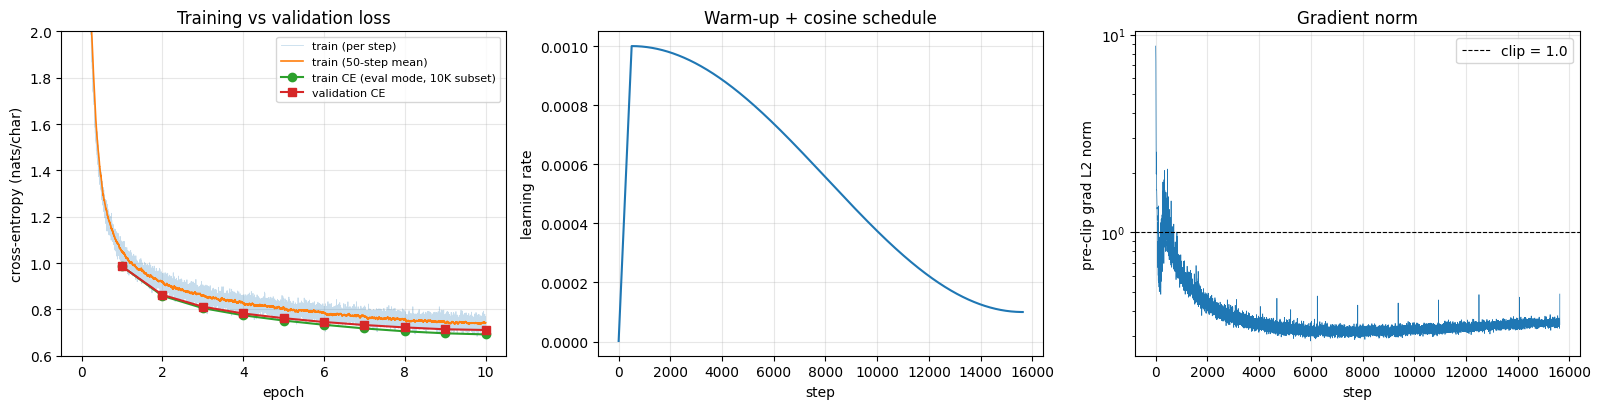

saved task1_llm/rajesh_paruchuri/outputs/loss_curves_full.png
epoch  1  train CE 0.9860  val CE 0.9853  val top-1 0.6918
epoch  2  train CE 0.8584  val CE 0.8625  val top-1 0.7298
epoch  3  train CE 0.8054  val CE 0.8117  val top-1 0.7449
epoch  4  train CE 0.7745  val CE 0.7823  val top-1 0.7535
epoch  5  train CE 0.7518  val CE 0.7621  val top-1 0.7594
epoch  6  train CE 0.7335  val CE 0.7455  val top-1 0.7645
epoch  7  train CE 0.7177  val CE 0.7326  val top-1 0.7683
epoch  8  train CE 0.7053  val CE 0.7221  val top-1 0.7716
epoch  9  train CE 0.6967  val CE 0.7141  val top-1 0.7738
epoch 10  train CE 0.6920  val CE 0.7111  val top-1 0.7746


In [7]:
ep = hist["epoch"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
w = 50
sm = np.convolve(hist["step_loss"], np.ones(w) / w, mode="valid")
ax[0].plot(np.array(hist["step"]) / len(hist["step"]) * len(ep), hist["step_loss"], alpha=0.25, lw=0.6, label="train (per step)")
ax[0].plot((np.arange(len(sm)) + w - 1) / len(hist["step"]) * len(ep), sm, lw=1.2, label=f"train ({w}-step mean)")
ax[0].plot(ep, hist["train_ce_eval"], "o-", label="train CE (eval mode, 10K subset)")
ax[0].plot(ep, hist["val_ce"], "s-", label="validation CE")
ax[0].set(xlabel="epoch", ylabel="cross-entropy (nats/char)", title="Training vs validation loss", ylim=(0.6, 2.0))
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].plot(hist["step"], hist["lr"]); ax[1].set(xlabel="step", ylabel="learning rate", title="Warm-up + cosine schedule"); ax[1].grid(alpha=0.3)
ax[2].plot(hist["step"], hist["grad_norm"], lw=0.5); ax[2].axhline(CFG["grad_clip"], color="k", ls="--", lw=0.8, label="clip = 1.0")
ax[2].set(xlabel="step", ylabel="pre-clip grad L2 norm", title="Gradient norm", yscale="log"); ax[2].legend(); ax[2].grid(alpha=0.3)
fig.tight_layout()
curve_path = P["out"] / f"loss_curves_{TAG}.png"
fig.savefig(curve_path, dpi=140); plt.show()
print("saved", R(curve_path))
for e, a, b, c in zip(ep, hist["train_ce_eval"], hist["val_ce"], hist["val_acc"]):
    print(f"epoch {e:2d}  train CE {a:.4f}  val CE {b:.4f}  val top-1 {c:.4f}")

In [8]:
# reload the best-validation checkpoint for every reported metric and sample
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model"])
print("using checkpoint from epoch", state["epoch"], "val CE %.4f" % state["val_ce"])

gen = torch.Generator().manual_seed(CFG["seed"])
samples, n_new_total, t_gen = [], 0, 0.0
for prompt in CFG["gen_prompts"]:
    p_ids = [EOS_ID] + cg.encode(prompt, char_to_idx).tolist()  # leading <|eos|> = "a new story starts"
    for temp in [0.0] + CFG["gen_temperatures"]:
        cg.sync(device); t0 = time.time()
        ids, n_new = cg.generate(model, p_ids, CFG["gen_max_new"], device, temperature=temp, eos_id=EOS_ID, generator=gen)
        cg.sync(device); t_gen += time.time() - t0; n_new_total += n_new
        text = cg.decode(ids[1:], idx_to_char)
        samples.append({"prompt": prompt, "decoding": "greedy" if temp == 0 else f"temperature={temp}",
                        "new_chars": n_new, "stopped_at_eos": text.endswith("<|eos|>"), "text": text})
gen_tok_per_sec = n_new_total / t_gen

sample_path = P["out"] / f"generated_samples_{TAG}.txt"
with open(sample_path, "w") as f:
    for i, s in enumerate(samples, 1):
        block = f"=== sample {i:02d} | {s['decoding']} | prompt: {s['prompt']!r} | new chars: {s['new_chars']} | stopped at eos: {s['stopped_at_eos']}\n{s['text']}\n"
        f.write(block + "\n"); print(block)
with open(P["out"] / f"generated_samples_{TAG}.json", "w") as f:
    json.dump(samples, f, indent=1)
print("generation speed: %.1f new chars/sec (single sequence, no KV cache)" % gen_tok_per_sec)

using checkpoint from epoch 10 val CE 0.7111


=== sample 01 | greedy | prompt: 'Once upon a time' | new chars: 400 | stopped at eos: False
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big box on the ground. It was a big box with a big smile on it. Lily was so excited to see what was inside.

"What is this?" she asked.

"It is a big box. It is a big box. It is so big and shiny. It is a big box. It is so big and shiny. It is a big box. It is so big and shiny. It is so big and shiny

=== sample 02 | temperature=0.7 | prompt: 'Once upon a time' | new chars: 400 | stopped at eos: False
Once upon a time, there was a little boy named Timmy. Timmy loved to play outside in the sunshine. One day, Timmy's mom told him they were playing in the park. They saw a big tree and his hoop on the shelf. The tree was sitting on a floor and the animals said, "Hello, tree. I will help you get it again." Lily looked at the tree and said, "See, it is a big shelf. It is big and beautifu

## Evaluation metrics
Every metric is computed from the best-validation checkpoint.
* **Cross-entropy** is the mean nats per character over every position of the 10K validation windows.
  Train CE uses a fixed 10K-window train subset in eval mode (dropout off), so the generalisation gap compares like with like.
  The running train loss (dropout on) is reported as well.
* **Perplexity** = exp(CE). **Bits per character** = CE / ln 2. **Generalisation gap** = val CE − train CE.
* **Top-1 accuracy** = share of validation positions where argmax(logits) equals the true next character.
* **Distinct-n** = unique word n-grams / total word n-grams, pooled per decoding strategy.
  **Repeated 4-gram rate** = share of word 4-grams that already occurred earlier in the same sample (averaged over samples).

In [9]:
import csv
# same fixed train subset that cg.train() scores each epoch
sub = torch.randperm(Xtr.size(0), generator=torch.Generator().manual_seed(CFG["seed"]))[:CFG["train_eval_subset"]]
tr_ce, tr_acc = cg.evaluate(model, Xtr[sub], Ytr[sub], device)
va_ce, va_acc = cg.evaluate(model, Xva, Yva, device)
best_ep = state["epoch"]
div = {d: cg.diversity_metrics([s["text"].replace("<|eos|>", " ") for s in samples if s["decoding"] == d])
       for d in sorted({s["decoding"] for s in samples})}
for d, m in div.items():
    print(f"{d:16s}", {k: round(v, 4) for k, v in m.items()})

main_div = div[f"temperature={CFG['gen_temperatures'][0]}"]
rows = [
    ("train_cross_entropy", tr_ce, "eval mode, fixed 10K train windows, best checkpoint"),
    ("train_cross_entropy_running", hist["train_loss_running"][best_ep - 1], "mean minibatch loss with dropout on, same epoch"),
    ("val_cross_entropy", va_ce, "all 10K val windows, best checkpoint"),
    ("val_perplexity", math.exp(va_ce), "exp(val_ce)"),
    ("train_perplexity", math.exp(tr_ce), "exp(train_ce)"),
    ("val_bits_per_character", va_ce / math.log(2), "val_ce / ln 2"),
    ("train_bits_per_character", tr_ce / math.log(2), "train_ce / ln 2"),
    ("generalization_gap", va_ce - tr_ce, "val_ce - train_ce (eval mode both)"),
    ("val_top1_next_char_accuracy", va_acc, "argmax == target over all val positions"),
    ("train_top1_next_char_accuracy", tr_acc, "same, on the 10K train subset"),
]
for d, m in div.items():
    key = d.replace("temperature=", "t")
    rows += [(f"distinct_1_{key}", m["distinct_1"], "word unigrams, pooled over 5 prompts"),
             (f"distinct_2_{key}", m["distinct_2"], "word bigrams"),
             (f"distinct_3_{key}", m["distinct_3"], "word trigrams"),
             (f"repeated_4gram_rate_{key}", m["repeated_4gram_rate"], "share of word 4-grams already seen in the same sample")]
rows += [
    ("grad_norm_mean", summary["grad_norm_mean"], "pre-clip L2 norm, all steps"),
    ("grad_norm_p99", summary["grad_norm_p99"], "pre-clip"),
    ("grad_norm_max", summary["grad_norm_max"], "pre-clip"),
    ("nan_count", summary["nan_count"], "non-finite loss or grad steps (skipped)"),
    ("loss_spike_count", summary["loss_spike_count"], "loss > 1.5x EMA after warm-up"),
    ("parameter_count", n_params, "tied LM head counted once"),
    ("train_tokens_per_sec", summary["train_tokens_per_sec"], "chars / training compute time (excl. eval)"),
    ("generation_tokens_per_sec", gen_tok_per_sec, "new chars/sec, batch 1, no KV cache"),
    ("peak_device_memory_mb", summary["peak_device_memory_mb"], "MPS driver allocated (cuda: max allocated)"),
    ("peak_process_rss_mb", summary["peak_process_rss_mb"], "whole Python process"),
    ("total_training_time_sec", summary["total_training_time_sec"], "wall clock incl. per-epoch eval"),
    ("epochs", summary["epochs"], ""),
    ("best_epoch", best_ep, "lowest val CE"),
    ("hardware", cg.hardware_string(device), ""),
]
csv_path = P["member"] / "metrics_report.csv" if not SMOKE else P["out"] / "metrics_report_smoke.csv"
with open(csv_path, "w", newline="") as f:
    wr = csv.writer(f); wr.writerow(["metric", "value", "notes"])
    for r in rows:
        wr.writerow(r)
for r in rows:
    print(f"{r[0]:34s} {r[1]:>16}" if not isinstance(r[1], float) else f"{r[0]:34s} {r[1]:16.4f}")
print("saved", R(csv_path))

greedy           {'distinct_1': 0.1828, 'distinct_2': 0.3846, 'distinct_3': 0.4807, 'repeated_4gram_rate': 0.3962, 'char_distinct_3': 0.2262, 'n_words': 443}
temperature=0.7  {'distinct_1': 0.3871, 'distinct_2': 0.8014, 'distinct_3': 0.9352, 'repeated_4gram_rate': 0.0047, 'char_distinct_3': 0.3838, 'n_words': 434}
temperature=1.0  {'distinct_1': 0.4811, 'distinct_2': 0.8794, 'distinct_3': 0.9716, 'repeated_4gram_rate': 0.0026, 'char_distinct_3': 0.4314, 'n_words': 424}
train_cross_entropy                          0.6920
train_cross_entropy_running                  0.7420
val_cross_entropy                            0.7111
val_perplexity                               2.0362
train_perplexity                             1.9977
val_bits_per_character                       1.0259
train_bits_per_character                     0.9983
generalization_gap                           0.0191
val_top1_next_char_accuracy                  0.7746
train_top1_next_char_accuracy                0.7794
distin

## 1.4 Sequence model failure analysis
The three failure cases, with snippets taken from `outputs/generated_samples_full.txt`, are written up in
`../failure_analysis.md` and summarised at the end of this notebook.